<a href="https://colab.research.google.com/github/rayPriyanka1/Research-Through-Data-Science/blob/main/Traffic_Congesion_System(Final).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-fuzzy


========== SMART TRAFFIC ANALYZER ==========
Running Automatic Experiments...

Results saved successfully.

   vehicle_density  speed  waiting_time  weather  road_occupancy  emergency  \
0               10      3           119        0               0          1   
1               15     73             4        5              24          0   
2               72     70           102        8              81          0   
3               79     97            67        2              46          0   
4               38     53            42        5               4          0   
5               56     24             8        1              54          1   
6               29      9            68        7              52          1   
7               75     63            23        7               0          1   
8                4     78            86        9              38          1   
9               16     71           119        2              47          1   

   congestion_value t

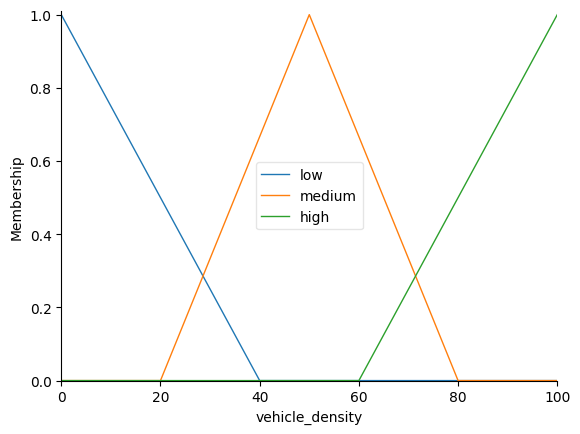

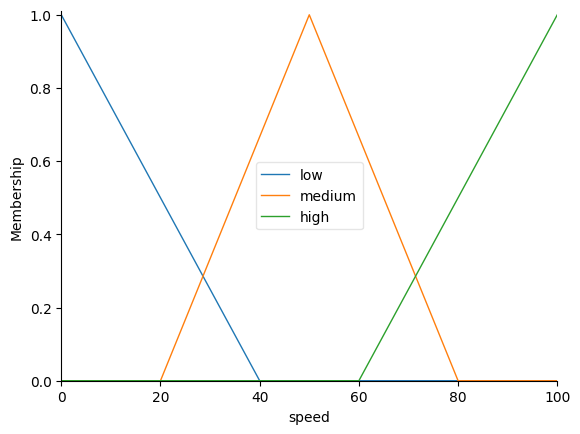

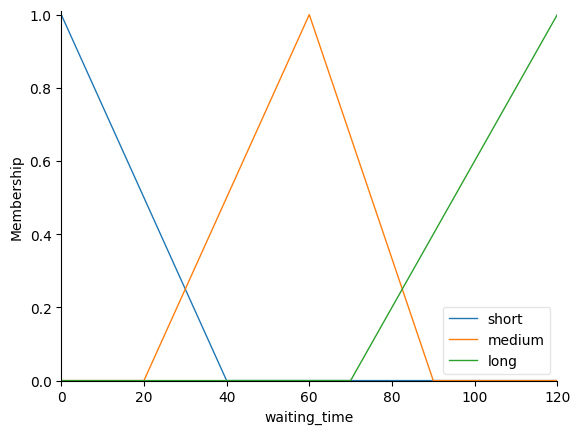

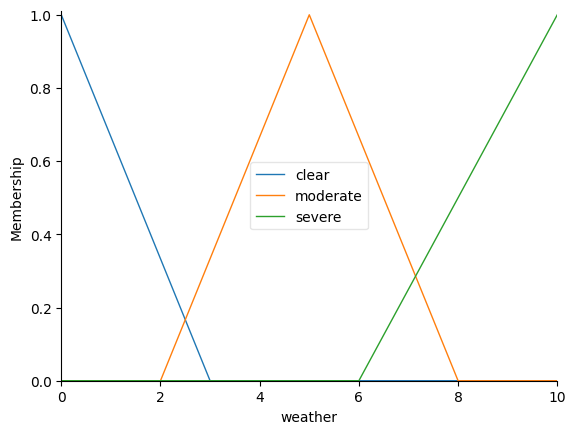

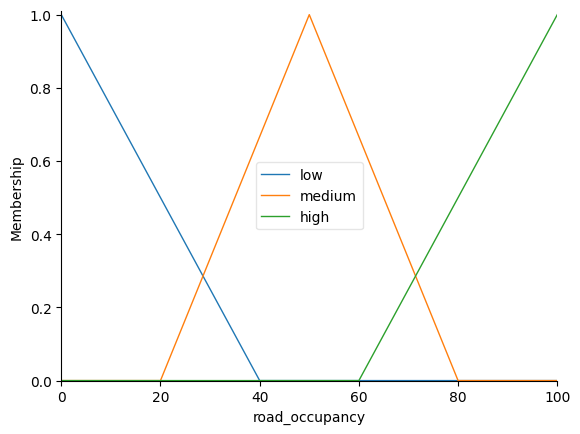

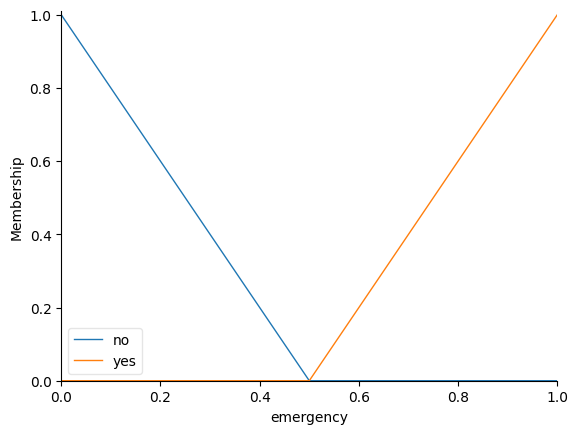

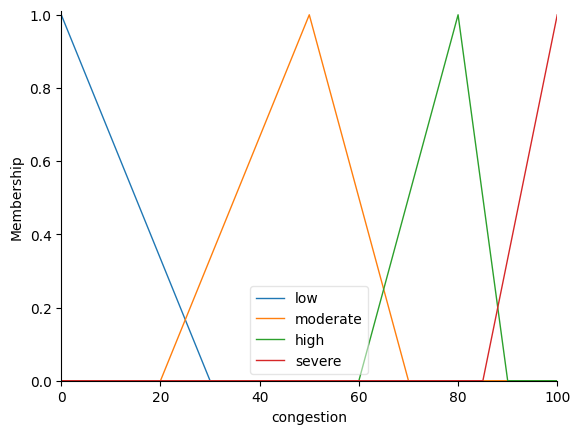

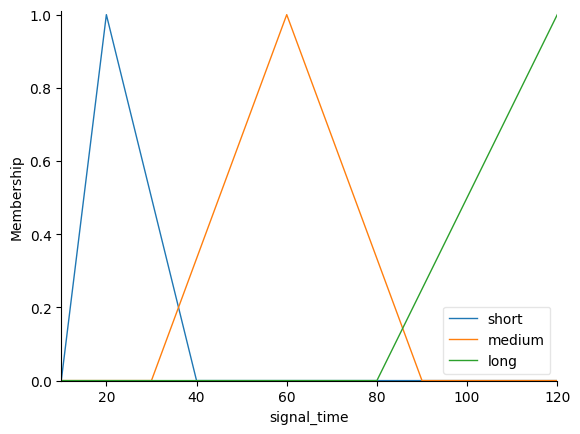

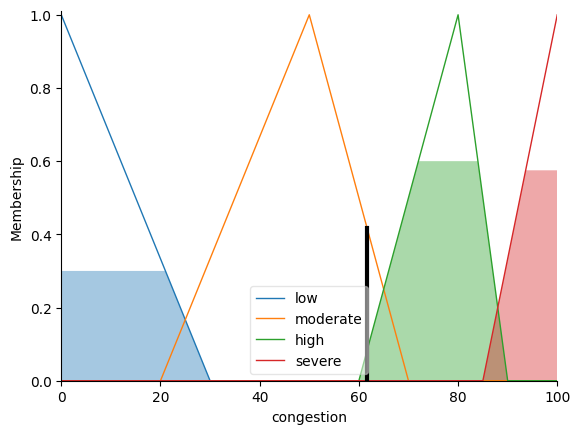

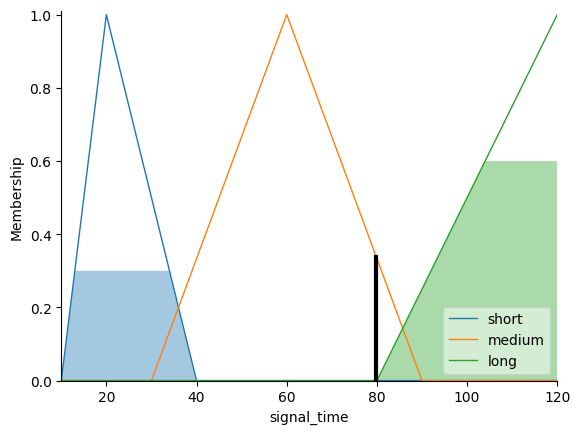

In [ ]:
import random
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# =====================================================
# INPUT VARIABLES
# =====================================================

vehicle_density = ctrl.Antecedent(
    np.arange(0, 101, 1),
    'vehicle_density'
)

speed = ctrl.Antecedent(
    np.arange(0, 101, 1),
    'speed'
)

waiting_time = ctrl.Antecedent(
    np.arange(0, 121, 1),
    'waiting_time'
)

weather = ctrl.Antecedent(
    np.arange(0, 11, 1),
    'weather'
)

road_occupancy = ctrl.Antecedent(
    np.arange(0, 101, 1),
    'road_occupancy'
)

emergency = ctrl.Antecedent(
    np.arange(0, 1.1, 0.1),
    'emergency'
)

# =====================================================
# OUTPUT VARIABLES
# =====================================================

congestion = ctrl.Consequent(
    np.arange(0, 101, 1),
    'congestion'
)

signal_time = ctrl.Consequent(
    np.arange(10, 121, 1),
    'signal_time'
)

# =====================================================
# MEMBERSHIP FUNCTIONS
# =====================================================

# VEHICLE DENSITY
vehicle_density['low'] = fuzz.trimf(
    vehicle_density.universe,
    [0, 0, 40]
)

vehicle_density['medium'] = fuzz.trimf(
    vehicle_density.universe,
    [20, 50, 80]
)

vehicle_density['high'] = fuzz.trimf(
    vehicle_density.universe,
    [60, 100, 100]
)

# SPEED
speed['low'] = fuzz.trimf(
    speed.universe,
    [0, 0, 40]
)

speed['medium'] = fuzz.trimf(
    speed.universe,
    [20, 50, 80]
)

speed['high'] = fuzz.trimf(
    speed.universe,
    [60, 100, 100]
)

# WAITING TIME
waiting_time['short'] = fuzz.trimf(
    waiting_time.universe,
    [0, 0, 40]
)

waiting_time['medium'] = fuzz.trimf(
    waiting_time.universe,
    [20, 60, 90]
)

waiting_time['long'] = fuzz.trimf(
    waiting_time.universe,
    [70, 120, 120]
)

# WEATHER
weather['clear'] = fuzz.trimf(
    weather.universe,
    [0, 0, 3]
)

weather['moderate'] = fuzz.trimf(
    weather.universe,
    [2, 5, 8]
)

weather['severe'] = fuzz.trimf(
    weather.universe,
    [6, 10, 10]
)

# ROAD OCCUPANCY
road_occupancy['low'] = fuzz.trimf(
    road_occupancy.universe,
    [0, 0, 40]
)

road_occupancy['medium'] = fuzz.trimf(
    road_occupancy.universe,
    [20, 50, 80]
)

road_occupancy['high'] = fuzz.trimf(
    road_occupancy.universe,
    [60, 100, 100]
)

# EMERGENCY
emergency['no'] = fuzz.trapmf(
    emergency.universe,
    [0, 0, 0, 0.5]
)

emergency['yes'] = fuzz.trapmf(
    emergency.universe,
    [0.5, 1, 1, 1]
)

# CONGESTION
congestion['low'] = fuzz.trimf(
    congestion.universe,
    [0, 0, 30]
)

congestion['moderate'] = fuzz.trimf(
    congestion.universe,
    [20, 50, 70]
)

congestion['high'] = fuzz.trimf(
    congestion.universe,
    [60, 80, 90]
)

congestion['severe'] = fuzz.trimf(
    congestion.universe,
    [85, 100, 100]
)

# SIGNAL TIME
signal_time['short'] = fuzz.trimf(
    signal_time.universe,
    [10, 20, 40]
)

signal_time['medium'] = fuzz.trimf(
    signal_time.universe,
    [30, 60, 90]
)

signal_time['long'] = fuzz.trimf(
    signal_time.universe,
    [80, 120, 120]
)


# FUZZY RULES


rules = [

    # BASIC RULES
    ctrl.Rule(
        vehicle_density['high'] &
        speed['low'],
        congestion['severe']
    ),

    ctrl.Rule(
        vehicle_density['medium'] &
        speed['medium'],
        congestion['moderate']
    ),

    ctrl.Rule(
        vehicle_density['low'] &
        speed['high'],
        congestion['low']
    ),

    # WAITING TIME RULES
    ctrl.Rule(
        waiting_time['long'],
        congestion['high']
    ),

    ctrl.Rule(
        waiting_time['short'] &
        vehicle_density['low'],
        congestion['low']
    ),

    # WEATHER RULES
    ctrl.Rule(
        weather['severe'] &
        speed['low'],
        congestion['high']
    ),

    ctrl.Rule(
        weather['clear'] &
        speed['high'],
        congestion['low']
    ),

    # ROAD OCCUPANCY RULES
    ctrl.Rule(
        road_occupancy['high'] &
        vehicle_density['high'],
        congestion['severe']
    ),

    ctrl.Rule(
        road_occupancy['medium'],
        congestion['moderate']
    ),

    # ADVANCED RULES
    ctrl.Rule(
        vehicle_density['high'] &
        waiting_time['long'] &
        road_occupancy['high'],
        congestion['severe']
    ),

    ctrl.Rule(
        vehicle_density['medium'] &
        weather['moderate'] &
        speed['medium'],
        congestion['moderate']
    ),

    ctrl.Rule(
        vehicle_density['high'] &
        weather['severe'],
        congestion['severe']
    ),

    ctrl.Rule(
        speed['low'] &
        waiting_time['long'],
        congestion['high']
    ),

    ctrl.Rule(
        speed['high'] &
        road_occupancy['low'],
        congestion['low']
    ),

    # EXTRA RULES TO AVOID MISSING OUTPUT
    ctrl.Rule(
        vehicle_density['medium'] &
        speed['high'],
        congestion['moderate']
    ),

    ctrl.Rule(
        vehicle_density['low'] &
        speed['medium'],
        congestion['low']
    ),

    ctrl.Rule(
        weather['moderate'] &
        road_occupancy['medium'],
        congestion['moderate']
    ),

    ctrl.Rule(
        vehicle_density['high'] &
        speed['high'],
        congestion['high']
    ),

    ctrl.Rule(
        road_occupancy['low'] &
        waiting_time['short'],
        congestion['low']
    ),

    # EMERGENCY RULE
    ctrl.Rule(
        emergency['yes'],
        signal_time['long']
    ),

    # SIGNAL RULES
    ctrl.Rule(
        congestion['low'],
        signal_time['short']
    ),

    ctrl.Rule(
        congestion['moderate'],
        signal_time['medium']
    ),

    ctrl.Rule(
        congestion['high'],
        signal_time['long']
    ),

    ctrl.Rule(
        congestion['severe'],
        signal_time['long']
    ),
]


# CONTROL SYSTEM


traffic_control = ctrl.ControlSystem(rules)


# AUTOMATIC EXPERIMENTS


results = []

print("\n========== SMART TRAFFIC ANALYZER ==========")
print("Running Automatic Experiments...\n")

for i in range(50):

    # CREATE NEW SIMULATION
    traffic_simulation = ctrl.ControlSystemSimulation(
        traffic_control
    )

    # RANDOM INPUTS
    vd = random.randint(0, 100)
    sp = random.randint(0, 100)
    wt = random.randint(0, 120)
    we = random.randint(0, 10)
    ro = random.randint(0, 100)
    em = random.randint(0, 1)

    # PASS INPUTS
    traffic_simulation.input['vehicle_density'] = vd
    traffic_simulation.input['speed'] = sp
    traffic_simulation.input['waiting_time'] = wt
    traffic_simulation.input['weather'] = we
    traffic_simulation.input['road_occupancy'] = ro
    traffic_simulation.input['emergency'] = em

    # COMPUTE
    traffic_simulation.compute()

    # SAFE OUTPUT CHECK
    if 'congestion' in traffic_simulation.output:
        cong_value = traffic_simulation.output['congestion']
    else:
        cong_value = 50

    if 'signal_time' in traffic_simulation.output:
        signal_value = traffic_simulation.output['signal_time']
    else:
        signal_value = 60

    # CONGESTION CATEGORY
    if cong_value < 30:
        congestion_status = "LOW"

    elif cong_value < 60:
        congestion_status = "MODERATE"

    elif cong_value < 85:
        congestion_status = "HIGH"

    else:
        congestion_status = "SEVERE"

    # SIGNAL CATEGORY
    if signal_value < 40:
        signal_status = "SHORT SIGNAL"

    elif signal_value < 80:
        signal_status = "MEDIUM SIGNAL"

    else:
        signal_status = "LONG SIGNAL"

    # STORE RESULTS
    results.append([
        vd,
        sp,
        wt,
        we,
        ro,
        em,
        round(cong_value, 2),
        congestion_status,
        round(signal_value, 2),
        signal_status
    ])


# DATAFRAME


df = pd.DataFrame(results, columns=[
    'vehicle_density',
    'speed',
    'waiting_time',
    'weather',
    'road_occupancy',
    'emergency',
    'congestion_value',
    'traffic_condition',
    'signal_time',
    'signal_status'
])


# SAVE CSV


df.to_csv(
    "experimental_results.csv",
    index=False
)

print("Results saved successfully.\n")


# SHOW RESULTS


print(df.head(10))


# VISUALIZATION


vehicle_density.view()
speed.view()
waiting_time.view()
weather.view()
road_occupancy.view()
emergency.view()

congestion.view()
signal_time.view()

# FINAL VISUALIZATION
congestion.view(sim=traffic_simulation)
signal_time.view(sim=traffic_simulation)

plt.show()


========== DATASET PREVIEW ==========

   vehicle_density  speed  waiting_time  weather  road_occupancy  emergency  \
0               10      3           119        0               0          1   
1               15     73             4        5              24          0   
2               72     70           102        8              81          0   
3               79     97            67        2              46          0   
4               38     53            42        5               4          0   

   congestion_value traffic_condition  signal_time  signal_status  
0             76.67              HIGH       106.67    LONG SIGNAL  
1             22.07               LOW        37.08   SHORT SIGNAL  
2             65.83              HIGH        85.27    LONG SIGNAL  
3             47.39          MODERATE        66.92  MEDIUM SIGNAL  
4             44.59          MODERATE        58.45  MEDIUM SIGNAL  

========== STATISTICAL SUMMARY ==========

       vehicle_density       spee

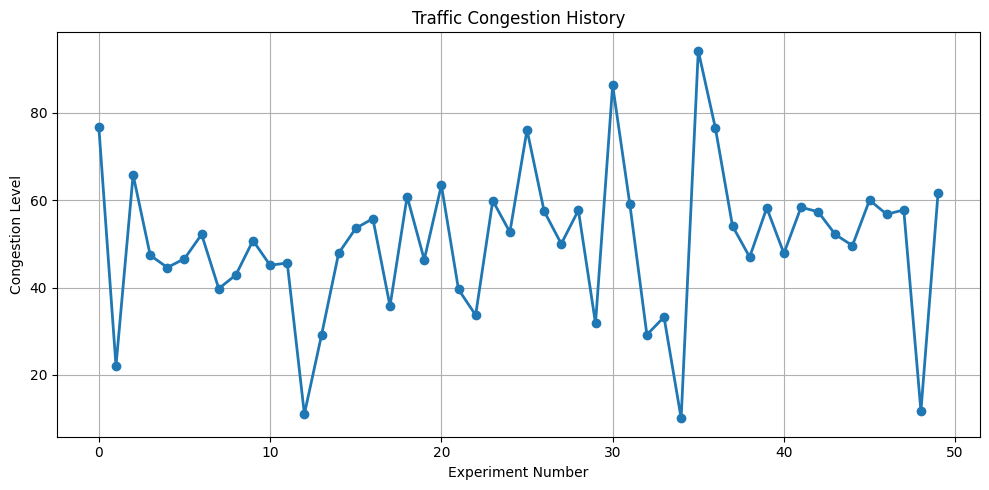

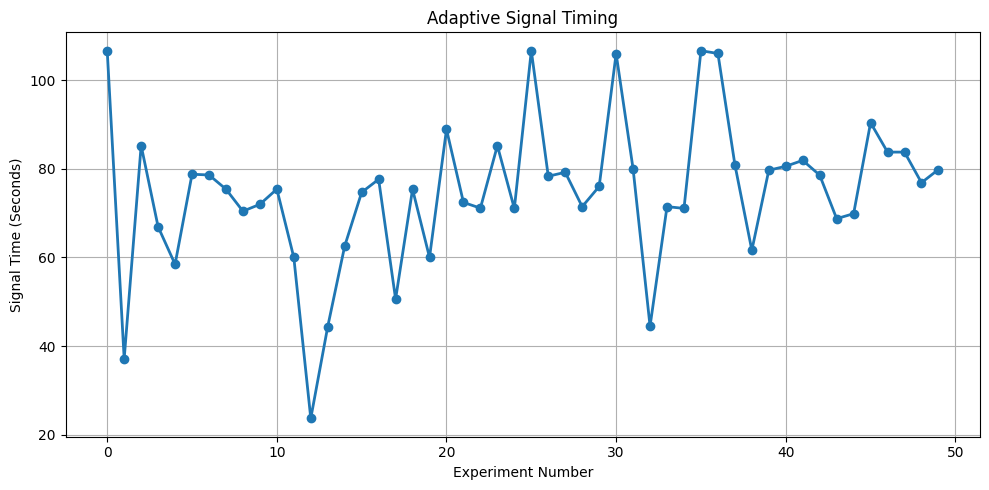

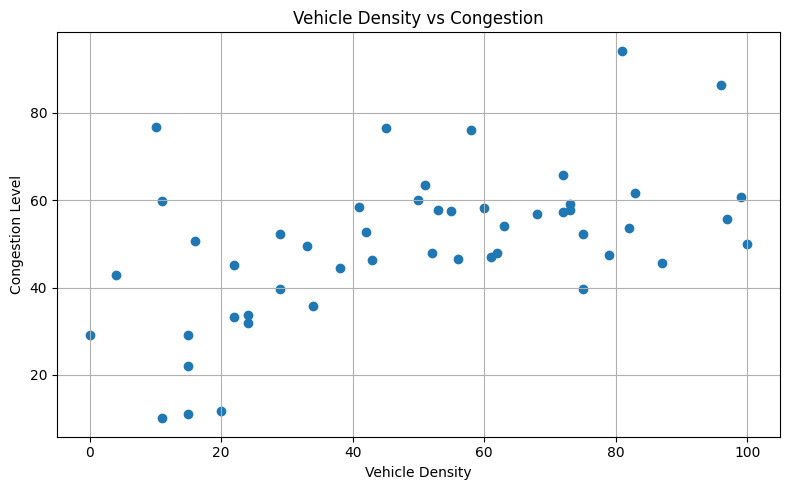

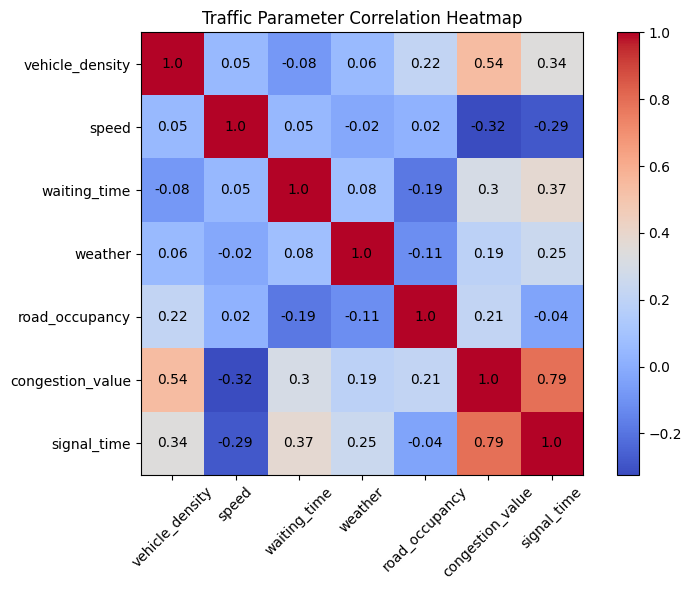

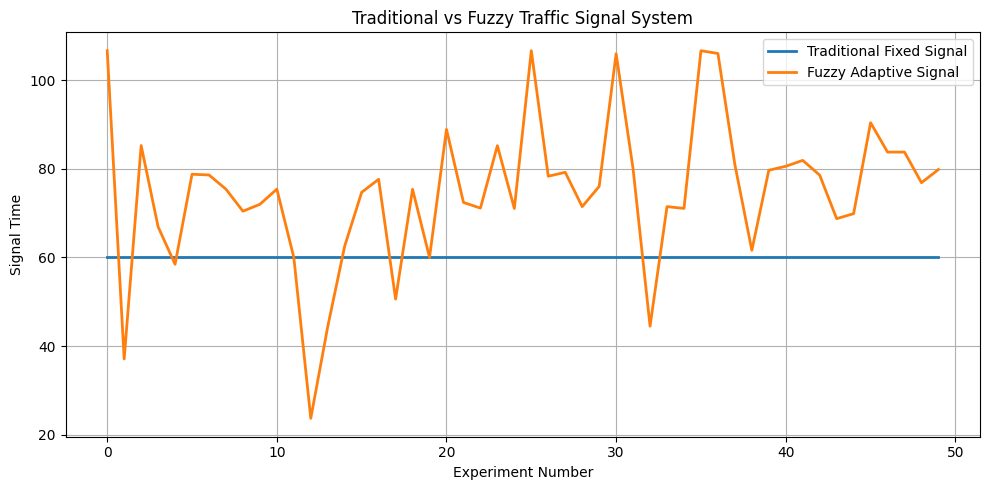


========== TRAFFIC CONDITION COUNT ==========

traffic_condition
MODERATE    34
HIGH         8
LOW          6
SEVERE       2
Name: count, dtype: int64


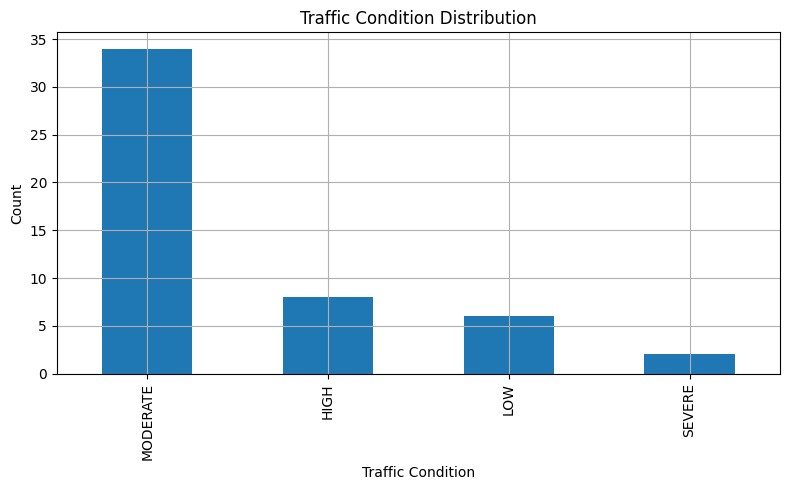


========== PERFORMANCE ANALYSIS ==========

Average Congestion Level: 50.07
Average Signal Time: 74.74
Maximum Congestion: 94.24
Minimum Congestion: 10.05
Maximum Signal Time: 106.67
Minimum Signal Time: 23.67

All graphs generated and saved successfully.


In [ ]:

# IMPORT LIBRARIES


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# LOAD DATASET


df = pd.read_csv("experimental_results.csv")

print("\n========== DATASET PREVIEW ==========\n")
print(df.head())


# BASIC STATISTICS


print("\n========== STATISTICAL SUMMARY ==========\n")
print(df.describe())


# GRAPH 1
# CONGESTION HISTORY


plt.figure(figsize=(10,5))

plt.plot(
    df['congestion_value'],
    linewidth=2,
    marker='o'
)

plt.title("Traffic Congestion History")

plt.xlabel("Experiment Number")

plt.ylabel("Congestion Level")

plt.grid(True)

plt.tight_layout()

plt.savefig("congestion_history.png")

plt.show()


# GRAPH 2
# SIGNAL TIMING HISTORY


plt.figure(figsize=(10,5))

plt.plot(
    df['signal_time'],
    linewidth=2,
    marker='o'
)

plt.title("Adaptive Signal Timing")

plt.xlabel("Experiment Number")

plt.ylabel("Signal Time (Seconds)")

plt.grid(True)

plt.tight_layout()

plt.savefig("signal_timing.png")

plt.show()


# GRAPH 3
# VEHICLE DENSITY VS CONGESTION


plt.figure(figsize=(8,5))

plt.scatter(
    df['vehicle_density'],
    df['congestion_value']
)

plt.title("Vehicle Density vs Congestion")

plt.xlabel("Vehicle Density")

plt.ylabel("Congestion Level")

plt.grid(True)

plt.tight_layout()

plt.savefig("density_vs_congestion.png")

plt.show()


# GRAPH 4
# CORRELATION HEATMAP


numeric_df = df[[
    'vehicle_density',
    'speed',
    'waiting_time',
    'weather',
    'road_occupancy',
    'congestion_value',
    'signal_time'
]]

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))

plt.imshow(
    correlation_matrix,
    cmap='coolwarm'
)

plt.colorbar()

labels = correlation_matrix.columns

plt.xticks(
    range(len(labels)),
    labels,
    rotation=45
)

plt.yticks(
    range(len(labels)),
    labels
)

# SHOW CORRELATION VALUES
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(
            j,
            i,
            round(correlation_matrix.iloc[i, j], 2),
            ha='center',
            va='center',
            color='black'
        )

plt.title("Traffic Parameter Correlation Heatmap")

plt.tight_layout()

plt.savefig("heatmap.png")

plt.show()


# GRAPH 5
# TRADITIONAL VS FUZZY SYSTEM


traditional_signal = [60] * len(df)

fuzzy_signal = df['signal_time']

plt.figure(figsize=(10,5))

plt.plot(
    traditional_signal,
    label='Traditional Fixed Signal',
    linewidth=2
)

plt.plot(
    fuzzy_signal,
    label='Fuzzy Adaptive Signal',
    linewidth=2
)

plt.legend()

plt.title("Traditional vs Fuzzy Traffic Signal System")

plt.xlabel("Experiment Number")

plt.ylabel("Signal Time")

plt.grid(True)

plt.tight_layout()

plt.savefig("fuzzy_vs_traditional.png")

plt.show()


# TRAFFIC CONDITION COUNT


condition_count = df['traffic_condition'].value_counts()

print("\n========== TRAFFIC CONDITION COUNT ==========\n")

print(condition_count)

# =====================================================
# BAR GRAPH
# =====================================================

plt.figure(figsize=(8,5))

condition_count.plot(
    kind='bar'
)

plt.title("Traffic Condition Distribution")

plt.xlabel("Traffic Condition")

plt.ylabel("Count")

plt.grid(True)

plt.tight_layout()

plt.savefig("traffic_distribution.png")

plt.show()

# =====================================================
# PERFORMANCE ANALYSIS
# =====================================================

print("\n========== PERFORMANCE ANALYSIS ==========\n")

print(
    "Average Congestion Level:",
    round(df['congestion_value'].mean(), 2)
)

print(
    "Average Signal Time:",
    round(df['signal_time'].mean(), 2)
)

print(
    "Maximum Congestion:",
    round(df['congestion_value'].max(), 2)
)

print(
    "Minimum Congestion:",
    round(df['congestion_value'].min(), 2)
)

print(
    "Maximum Signal Time:",
    round(df['signal_time'].max(), 2)
)

print(
    "Minimum Signal Time:",
    round(df['signal_time'].min(), 2)
)

print("\nAll graphs generated and saved successfully.")